In [1]:
import os
import struct
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans, DBSCAN
from agcounts_filter import convert_AC
from datetime import datetime
from scipy.stats import mode

Récupération des données et des annotations

In [2]:
"""****************************************** Epoch de 2s pour le seuil à 75 ***********************************************************"""

folder_path = "C:/Users/roman/Documents/BEaCHILD/X_et_Y" 
folder = os.listdir(folder_path)


# Initialisation des listes contenant les données des capteurs
X_non_dom = []
X_dom = []

# Initialisation des listes contenant les annotations vidéos
Y_non_dom = [] 
Y_dom = []


#Parcourir les fichiers CSV
for file in folder[4:7]: #[0:7]
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    # Pour les cas ou il y a des annotations avant le start
    allow_start_dom = None
    allow_start_non_dom = None

    """********************************************************************** 1. Lecture des fichiers csv ******************************************************************************"""
    if extension == ".csv":

        # Visualisation des données des capteurs
        data_file = pd.read_csv(folder_path + "/" + file, header = 5, names = ["Timestamp","Gyro X","Gyro Y","Gyro Z","Accelerometer X","Accelerometer Y","Accelerometer Z","Event","Quat W","Quat X","Quat Y","Quat Z","None"])    

        # Conversion en AC 
        dom_AC = convert_AC(folder_path + "/" + file)

        # Enregistrement des données des capteurs dans les listes qui seront donnnées au classificateur
        if file[-11:-4] == "non_dom":
            list_dom_AC = dom_AC["AC"].tolist() # Conversion du type pd.serie en type list
            for ac in list_dom_AC :
                X_non_dom.append(ac)

        elif file[-7:-4] == "dom":
            list_dom_AC = dom_AC["AC"].tolist()
            for ac in list_dom_AC:
                X_dom.append(ac)

    """********************************************************** 2. Enregistrer les annotations ***************************************************************************"""

    if extension == ".xlsx":

        start_dom = True
        start_non_dom = True 

        my_wb = openpyxl.load_workbook(folder_path + "/" + file) 
        my_sheet = my_wb.active

        # Initialisation des décalages : sert pour éviter le décalage du aux arrondis des annotations 
        decalage_dom = 0
        decalage_non_dom = 0

        for label in my_sheet["H"]: 

            """*********************************************** Récupération du début de Y ****************************************************"""
            # dom
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_LW" :
                """if int(round(float(my_sheet.cell(label.row, 12).value))) < float(my_sheet.cell(label.row, 12).value):
                    start_sensor = (int(round(float(my_sheet.cell(label.row, 12).value)) + 1) / 2) # RAJOUT DE /2
                else:
                    start_sensor = int(round(float(my_sheet.cell(label.row, 12).value)) / 2) # RAJOUT DE /2
                #decalage_dom += start_sensor - float(my_sheet.cell(label.row, 12).value)
                #Ajouter un nb start_sensor de none au début
                for decalage in range(start_sensor):
                    Y_dom.append(None) #.append("différent start droit")"""
                previous_row_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_dom = True

            # non_dom 
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_RW" :
                """if int(round(float(my_sheet.cell(label.row, 12).value))) < float(my_sheet.cell(label.row, 12).value):
                    start_sensor = (int(round(float(my_sheet.cell(label.row, 12).value)) + 1) /2) # Rajout du /2
                else:
                    start_sensor = int(round(float(my_sheet.cell(label.row, 12).value))/ 2)  # Rajout du / 2
                decalage_non_dom += start_sensor - float(my_sheet.cell(label.row, 12).value)
                #Ajouter un nb start_sensor de none au début
                for decalage in range(start_sensor):
                    Y_non_dom.append(None) #append("différent start gauche")"""
                previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_non_dom = True

            """****************************************************** Récupération du contenu de Y ****************************************"""

            if label.value[0:2] == "LW" and allow_start_dom:

                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_dom, 13).value:
                    difference = round((float(my_sheet.cell(row, 12).value) - float(my_sheet.cell(previous_row_dom , 13).value)) / 2)  #(round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_dom , 13).value))
                    for diff in range(0, difference):
                        Y_dom.append(None) #.append("décalage annotations")
                    
                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = round((float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(label.row, 12).value)) /2)# nb_repetitions = (int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value))))
                #nb_rep = int(round(nb_repetitions))
                for nb_sec in range(nb_repetitions): 
                    if X_dom and (len(Y_dom) == len(X_dom)) :
                        break
                    if label.value[3:13] == "sédentaire":
                        # Y_dom[idx_Y_dom].append("non mouvement")
                        Y_dom.append("non mouvement")
                    elif label.value[3:7] =="mouv":
                        #Y_dom[idx_Y_dom].append("mouvement")
                        Y_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        #Y_dom[idx_Y_dom].append("non noté") #.append(None) 
                        Y_dom.append(None) #("non noté")

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_dom = label.row


            elif label.value[0:2] == "RW" and allow_start_non_dom:
                
                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_non_dom, 13).value:
                    difference = round((float(my_sheet.cell(row, 12).value) - float(my_sheet.cell(previous_row_non_dom , 13).value)) /2) # difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_non_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_non_dom.append(None) #.append("décalage annotations")

                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = round((float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(label.row, 12).value)) /2) # nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value)))
                #nb_repetitions = int(round(nb_repetitions))
                for nb_sec in range(0,nb_repetitions): 
                    if X_non_dom and (len(Y_non_dom) == len(X_non_dom)): 
                        break
                    if label.value[3:13] == "sédentaire":
                        Y_non_dom.append("non mouvement")
                    elif label.value[3:7] =="mouv":
                        Y_non_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_non_dom.append(None)

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_non_dom = label.row

        print(f"len(X_dom) {len(X_dom)}")
        # CROPER X A L A LONGUEUR DE Y 
        X_dom = X_dom[:len(Y_dom)]
        X_non_dom = X_non_dom[:len(Y_non_dom)]
        Y_dom = Y_dom[:len(X_dom)]
        Y_non_dom = Y_non_dom[:len(X_non_dom)]

        print(f"len X_dom {X_dom[257 : 285]}")
        print(f"len Y_dom {Y_dom[257 : 285]}")
        



On est dans le fichier : Data_11_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_11_non_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_11_X.xlsx
len(X_dom) 13403
len X_dom [142.87407042567241, 68.60029154456998, 33.54101966249684, 67.05221845696084, 12.165525060596439, 108.0, 319.62478001556764, 299.0066888883926, 294.24479604574145, 267.5892374517331, 381.93847672105517, 68.4470598345904, 2.0, 5.0990195135927845, 261.5893728728291, 303.606653418531, 0.0, 232.16588896735024, 613.959282037498, 544.2324870861717, 218.8880992653552, 193.93297811357408, 395.37956446938426, 181.96977771047588, 270.6325922722539, 11.661903789690601, 0.0, 115.43396380615195]
len Y_dom ['mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'non mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement

Analyse métriques

1627


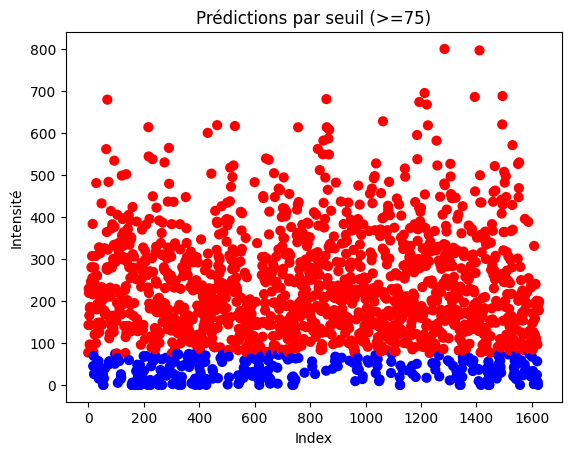

Accuracy pour seuil > 75 : 0.82


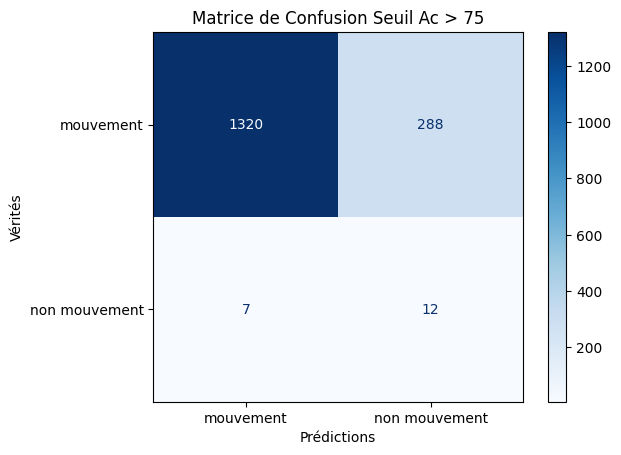

In [3]:
# Convertir en array pour faciliter le filtrage
X_array = np.array(X_dom)
Y_array = np.array(Y_dom)
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_None = Y_array != None
# Appliquer le masque
X_clean = X_array[mask_None]
Y_clean = Y_array[mask_None]

X_flat = np.vstack(X_clean)
Y_flat = np.vstack(Y_clean)

# PAS BESOIN D'EQUILIBRER LES DONNEES ?
#Equilibrer les données : autant de mouvement que de non mouvement, et dans le meme ordre que X_array et Y_array


#********************************* Seuil AC > 75 **********************************************************************************
#On a X_dom et Y_dom : construire un Y_pred_2 et le comparer à Y_dom
Y_pred_75 = []

for idx_data in range(0,len(X_flat)):
    #seuil = X_flat[idx_data] + X_flat[idx_data+1] # //////////////////////////
    seuil = X_flat[idx_data]
    if seuil >= 75 :
        Y_pred_75.append("mouvement")
    elif seuil < 75 :
        Y_pred_75.append("non mouvement")
    else:
        Y_pred_75.append(None)

print(len(X_flat))

# Crée un mapping de couleur pour chaque label
label_to_color = {'mouvement': 'red', 'non mouvement': 'blue'}
colors = [label_to_color[y] for y in Y_pred_75]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(X_flat)), X_flat[:, 0], c=colors, s=40)
plt.title("Prédictions par seuil (>=75)")
plt.xlabel("Index")
plt.ylabel("Intensité")
plt.show()

# Evaluate the model
accuracy = accuracy_score(Y_flat, Y_pred_75)
print(f"Accuracy pour seuil > 75 : {accuracy:.2f}")
cm_75 = confusion_matrix(Y_flat, Y_pred_75)

# Afficher la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm_75, display_labels= ["mouvement", "non mouvement"])
disp.plot(cmap="Blues")
disp.ax_.set_title("Matrice de Confusion Seuil Ac > 75")
disp.ax_.set_xlabel("Prédictions")
disp.ax_.set_ylabel("Vérités")
#disp.figure_.show()
plt.show()